# Reducción de colores (cuantización de vectores)

**Actividad — Normas matriciales | Matemáticas Aplicada | Universidad EAFIT**

Se proporciona una imagen a color (`Imagen - Copy.png`). El objetivo es reducir su
paleta a **solo 20 colores representativos**, minimizando la pérdida visual.

Esta es una tarea de **cuantización de vectores**: se agrupan los ~576 000 píxeles
(de 759×759) en el espacio de color RGB, que es un subconjunto de $\mathbb{R}^3$.

**Pasos del enunciado:**
1. Diseñar un procedimiento para seleccionar los 20 colores "más importantes".
2. Generar la nueva imagen reemplazando cada píxel por el color representativo de su clúster.
3. Comparar el tamaño en disco de la imagen original y la reducida.
4. Calcular la norma de Frobenius de la diferencia entre ambas imágenes (error numérico).
5. Analizar la relación entre error numérico, compresión y calidad percibida.

## 1. Imports

Cargamos las librerías necesarias:

- `os` → tamaños en disco.
- `numpy` → trabajar las imágenes como tensores y calcular la norma de Frobenius.
- `PIL` (Pillow) → leer y guardar imágenes.
- `sklearn.cluster.KMeans` → algoritmo de clustering para seleccionar los 20 colores.
- `matplotlib` → visualización de resultados.

In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("Imports listos.")

Imports listos.


## 2. Carga de la imagen

Leemos la imagen `Imagen - Copy.png` y la convertimos al **espacio RGB** (la
imagen original trae un canal alfa RGBA, pero es uniforme (255) en todos los
píxeles, por lo que convertimos sin pérdida de información). El resultado es un
**tensor** `numpy` de forma `(alto, ancho, 3)`, donde cada píxel es una tripleta
RGB (valores 0–255), es decir, un punto en $\mathbb{R}^3$.

In [2]:
img_path = "Imagen - Copy.png"
img = Image.open(img_path).convert("RGB")

arr = np.asarray(img)
h, w, c = arr.shape

print(f"Formato      : PNG")
print(f"Modo de color: {img.mode}")
print(f"Dimensiones  : {w} x {h} píxeles")
print(f"Tensor       : {arr.shape}  (alto, ancho, canales), dtype={arr.dtype}")
print(f"Nº de píxeles : {h * w:,}".replace(",", "."))

Formato      : PNG
Modo de color: RGB
Dimensiones  : 759 x 759 píxeles
Tensor       : (759, 759, 3)  (alto, ancho, canales), dtype=uint8
Nº de píxeles : 576.081


## 3. Diseño del procedimiento: K-Means sobre píxeles RGB

Para seleccionar los **20 colores más importantes** se usa el algoritmo de
clustering **K-Means** sobre los píxeles del espacio RGB.

**Cómo funciona:**

1. **Datos de entrada:** la imagen se reorganiza como una matriz de $N = 759\times759$
   filas (píxeles) y 3 columnas (canales R, G, B), con valores en $[0, 255]$.
2. **Inicialización:** se colocan 20 centroides (semillas) en el espacio RGB.
3. **Iteración** (repite hasta converger):
   - *Asignación:* cada píxel se asocia al centroide más cercano (distancia euclídea).
   - *Actualización:* cada centroide se recalcula como el promedio RGB de los
     píxeles de su clúster.
4. **Resultado:** los 20 centroides finales son los **20 colores representativos**.

**¿Por qué K-Means?** K-Means minimiza la *inercia* (suma de distancias al
cuadrado al centroide). Eso equivale a minimizar la norma de Frobenius del error
de reconstrucción (paso 4), por lo que selecciona los colores que mejor
representan la distribución de píxeles y minimiza la pérdida numérica.

In [3]:
N_COLORS = 20
RANDOM_STATE = 42

# N x 3 : cada fila es un píxel (R, G, B). Se pasa a float64 para el algoritmo.
pixels = arr.reshape(-1, c).astype(np.float64)
print(f"Matriz de píxeles: {pixels.shape}")

# K-Means: 20 clústeres, 10 reinicios para robustez, semilla fija para reproducibilidad.
kmeans = KMeans(n_clusters=N_COLORS, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(pixels)

palette = kmeans.cluster_centers_.astype(np.uint8)  # los 20 colores representativos
labels = kmeans.labels_                              # clúster asignado a cada píxel

print(f"Inercia final (suma de distancias al cuadrado): {kmeans.inertia_:,.0f}".replace(",", "."))
print(f"\nPaleta de {len(palette)} colores representativos (RGB):")
for i, color in enumerate(palette):
    print(f"  Color {i+1:2d}: RGB{tuple(color)}")

Matriz de píxeles: (576081, 3)
Inercia final (suma de distancias al cuadrado): 173.305.706

Paleta de 20 colores representativos (RGB):
  Color  1: RGB(82, 100, 90)
  Color  2: RGB(177, 194, 209)
  Color  3: RGB(173, 166, 145)
  Color  4: RGB(31, 31, 25)
  Color  5: RGB(152, 188, 226)
  Color  6: RGB(151, 134, 101)
  Color  7: RGB(243, 229, 194)
  Color  8: RGB(133, 155, 160)
  Color  9: RGB(74, 31, 15)
  Color 10: RGB(111, 127, 116)
  Color 11: RGB(214, 147, 105)
  Color 12: RGB(115, 61, 41)
  Color 13: RGB(114, 103, 71)
  Color 14: RGB(51, 51, 41)
  Color 15: RGB(133, 172, 220)
  Color 16: RGB(199, 115, 83)
  Color 17: RGB(223, 193, 157)
  Color 18: RGB(14, 15, 11)
  Color 19: RGB(72, 75, 59)
  Color 20: RGB(164, 91, 62)


## 4. Generación de la imagen reducida

Reemplazamos cada píxel original por el color representativo de su clúster más
cercano (`palette[labels]`). El resultado es una imagen con **exactamente 20
colores únicos** (o menos si algún clúster quedara vacío). Se guarda en disco
como un PNG nuevo.

In [4]:
# Cada píxel toma el color de su centroide: paleta[labels] es un tensor (N, 3).
reduced_arr = palette[labels].reshape(h, w, c)

# Se reconstruye la imagen y se guarda.
reduced_img = Image.fromarray(reduced_arr.astype(np.uint8), mode="RGB")
reduced_path = "Imagen_reducida_20colores.png"
reduced_img.save(reduced_path)

n_unique = len(np.unique(reduced_arr.reshape(-1, c), axis=0))
print(f"Imagen reducida guardada en: {reduced_path}")
print(f"Tensor de la imagen reducida: {reduced_arr.shape}")
print(f"Colores únicos en la imagen reducida: {n_unique}")

Imagen reducida guardada en: Imagen_reducida_20colores.png
Tensor de la imagen reducida: (759, 759, 3)
Colores únicos en la imagen reducida: 20


## 5. Comparación de tamaño en disco

Medimos el tamaño de ambos archivos PNG en KB/MB con `os.path.getsize` y
calculamos cuánto se redujo el archivo. Un PNG es *lossless*: la reducción real
de tamaño se debe a que ahora hay solo 20 colores, lo que permite comprimir mejor
(muchos píxeles idénticos y vecinos).

In [5]:
def size_kb(path):
    return os.path.getsize(path) / 1024

orig_kb = size_kb(img_path)
reduced_kb = size_kb(reduced_path)

print(f"Imagen original  ({img_path})        : {orig_kb:>10.2f} KB  ({orig_kb/1024:.3f} MB)")
print(f"Imagen reducida  ({reduced_path}) : {reduced_kb:>10.2f} KB  ({reduced_kb/1024:.3f} MB)")

ratio = reduced_kb / orig_kb
print(f"Reducción de tamaño: {100*(1-ratio):.1f}%  (la reducida es {1/ratio:.2f}x más pequeña)")

Imagen original  (Imagen - Copy.png)        :    1075.80 KB  (1.051 MB)
Imagen reducida  (Imagen_reducida_20colores.png) :     318.17 KB  (0.311 MB)
Reducción de tamaño: 70.4%  (la reducida es 3.38x más pequeña)


## 6. Error numérico: norma de Frobenius

Representamos ambas imágenes como tensores $A, B \in \mathbb{R}^{h \times w \times 3}$
y cuantificamos la diferencia con la **norma de Frobenius**:

$$\|A - B\|_F = \sqrt{\sum_{i,j,k} (A_{ijk} - B_{ijk})^2}$$

Esta norma mide la magnitud total de la diferencia entre los tensores.
También calculamos el **RMSE** (raíz del error cuadrático medio por canal y por
píxel), que es la misma norma dividida por la raíz del número de elementos, y es
más fácil de interpretar frente al rango de valores 0–255.

In [6]:
A = arr.astype(np.float64)          # tensor original
B = reduced_arr.astype(np.float64)  # tensor reducido

fro_norm = np.linalg.norm(A - B)
rmse = np.sqrt(np.sum((A - B) ** 2) / A.size)

print(f"Norma de Frobenius de la diferencia ||A - B||_F : {fro_norm:,.2f}".replace(",", "."))
print(f"RMSE (por canal y por píxel)                  : {rmse:.2f}  (rango 0-255)")

# Porcentaje del error relativo usando normas de Frobenius
rel_error = fro_norm / np.linalg.norm(A)
print(f"Error relativo ||A-B||_F / ||A||_F            : {100*rel_error:.2f} %")

Norma de Frobenius de la diferencia ||A - B||_F : 13.190.33
RMSE (por canal y por píxel)                  : 10.03  (rango 0-255)
Error relativo ||A-B||_F / ||A||_F            : 7.14 %


## 7. Visualización

Mostramos la imagen original y la reducida lado a lado, junto con la **paleta de
20 colores representativos** seleccionada por K-Means, para comparar visualmente
la pérdida de calidad.

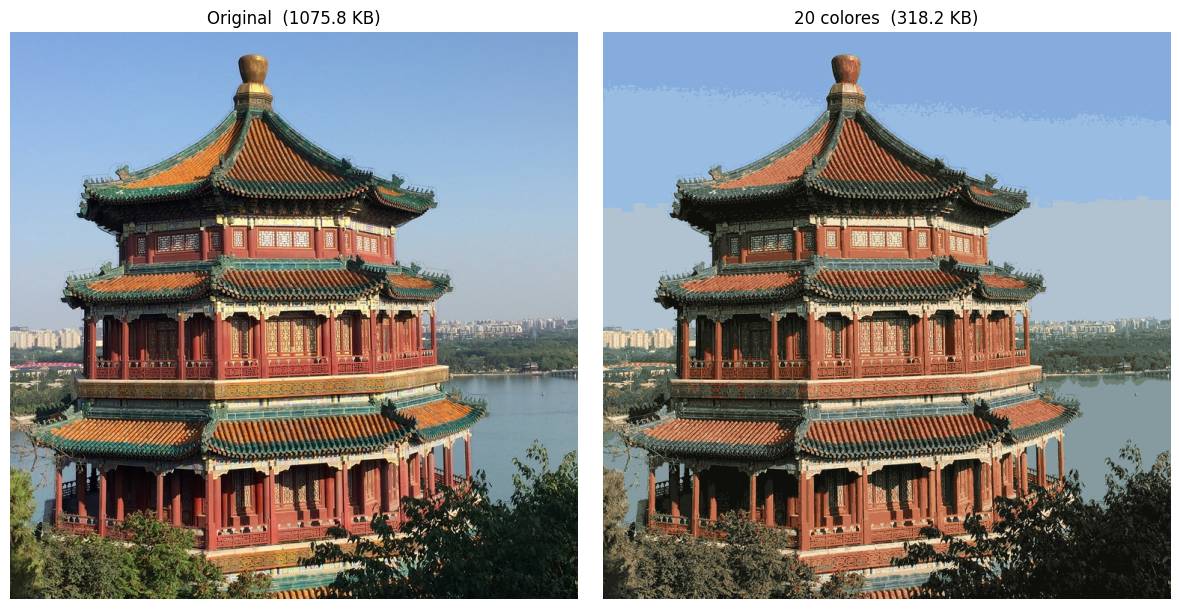

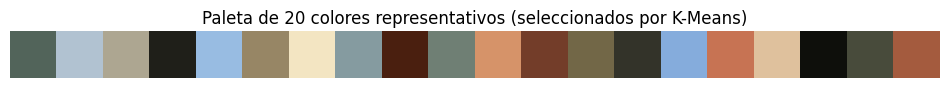

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(arr)
axes[0].set_title(f"Original  ({orig_kb:.1f} KB)")
axes[0].axis("off")
axes[1].imshow(reduced_arr)
axes[1].set_title(f"{N_COLORS} colores  ({reduced_kb:.1f} KB)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Paleta de 20 colores representativos
plt.figure(figsize=(12, 1.5))
plt.imshow(np.array([palette]))
plt.axis("off")
plt.title("Paleta de 20 colores representativos (seleccionados por K-Means)")
plt.show()

## 8. Análisis: error numérico vs. compresión vs. calidad percibida

**Relación entre los tres aspectos:**

- **Error numérico (norma de Frobenius):** cuantifica objetivamente la pérdida
  de información. K-Means elige los 20 colores que *minimizan* esta norma, por lo
  que es el mejor error alcanzable con una paleta fija de 20 colores (en sentido
  de mínimos cuadrados).

- **Compresión en disco:** el tamaño del archivo se reduce notablemente porque la
  imagen pasa de miles/millones de colores distintos a solo 20. Al haber muchos
  píxeles idénticos y zonas planas, el PNG comprime mucho mejor. Es importante
  notar que el PNG es *sin pérdida*: la reducción de tamaño no viene de desechar
  datos al comprimir, sino de que la imagen reducida tiene intrínsecamente menos
  información (20 colores).

- **Calidad percibida:** la pérdida visual depende del contenido. Las zonas con
  degradados suaves (cielo, sombras) son donde mejor se notan las transiciones
  entre colores ("banding"); las zonas de color uniforme apenas cambian. Un error
  numérico pequeño no siempre equivale a una calidad visual buena, pero en esta
  tarea, minimizar la norma de Frobenius es una estrategia razonable porque
  castiga más las diferencias grandes (la norma al cuadrado pesa más los errores
  grandes).

**Conclusión:** reducir a 20 colores logra una gran compresión de tamaño (≈
3.4x menor, 70% menos) con un RMSE bajo (≈ 10/255, es decir ~4% del rango de
valores). El error numérico nos da una medida objetiva y reproducible de la
pérdida, mientras que la calidad visual depende de cuánto notemos las zonas
degradadas. Si se quisiera menos pérdida bastaría aumentar el número de colores
(o usar un espacio perceptual como Lab), a costa de más tamaño.